In [1]:
import os
import shutil
import xml.etree.ElementTree as ET

INPUT_FOLDER = '../../data/anpr/sri_lanka_plates/' 
OUTPUT_FOLDER = '../../data/anpr/SriLankan_YOLO/'

os.makedirs(os.path.join(OUTPUT_FOLDER, 'train/images'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_FOLDER, 'train/labels'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_FOLDER, 'valid/images'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_FOLDER, 'valid/labels'), exist_ok=True)

def convert_bbox(size, box):
    """Converts XML box (xmin, xmax, ymin, ymax) to YOLO math (x, y, w, h)."""
    dw, dh = 1. / size[0], 1. / size[1]
    x = (box[0] + box[1]) / 2.0
    y = (box[2] + box[3]) / 2.0
    w, h = box[1] - box[0], box[3] - box[2]
    return (x * dw, y * dh, w * dw, h * dh)

In [2]:
import glob
import random

xml_files = glob.glob(os.path.join(INPUT_FOLDER, '*.xml'))
random.shuffle(xml_files)
train_split = int(len(xml_files) * 0.8)

for i, xml_path in enumerate(xml_files):
    split_name = 'train' if i < train_split else 'valid'
    base_name = os.path.basename(xml_path).replace('.xml', '')
    
    img_path = None
    for ext in ['.jpg', '.jpeg', '.png']:
        if os.path.exists(os.path.join(INPUT_FOLDER, base_name + ext)):
            img_path = os.path.join(INPUT_FOLDER, base_name + ext)
            break
            
    if not img_path: continue

    tree = ET.parse(xml_path)
    root = tree.getroot()
    size = root.find('size')
    w, h = int(size.find('width').text), int(size.find('height').text)
    
    with open(os.path.join(OUTPUT_FOLDER, split_name, 'labels', f"{base_name}.txt"), 'w') as out_file:
        for obj in root.iter('object'):
            xmlbox = obj.find('bndbox')
            b = (float(xmlbox.find('xmin').text), float(xmlbox.find('xmax').text),
                 float(xmlbox.find('ymin').text), float(xmlbox.find('ymax').text))
            bb = convert_bbox((w, h), b)
            out_file.write(f"0 {' '.join([str(a) for a in bb])}\n")
            
    shutil.copy(img_path, os.path.join(OUTPUT_FOLDER, split_name, 'images', os.path.basename(img_path)))

print("✅ YOLO Dataset generated successfully!")

yaml_content = f"""path: {os.path.abspath(OUTPUT_FOLDER)}
train: train/images
val: valid/images

names:
  0: license-plate
"""
with open(os.path.join(OUTPUT_FOLDER, 'data.yaml'), 'w') as f:
    f.write(yaml_content)
print("✅ data.yaml configuration file created!")

✅ YOLO Dataset generated successfully!
✅ data.yaml configuration file created!


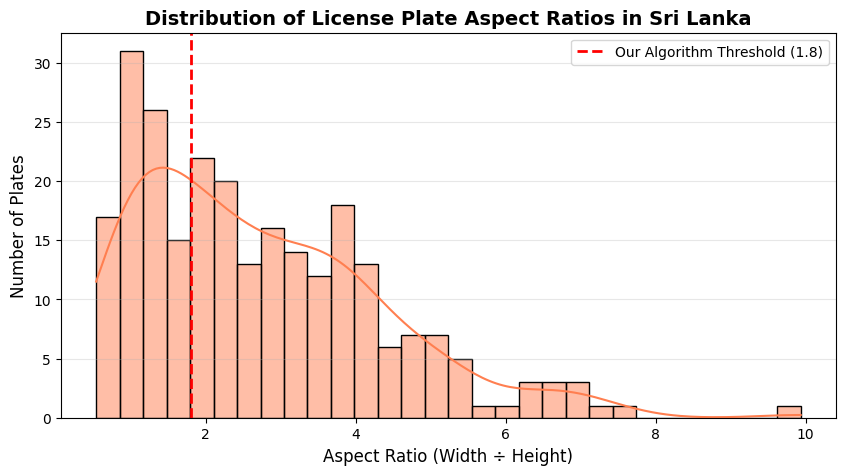

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import pandas as pd

label_files = glob.glob('../../data/anpr/SriLankan_YOLO/train/labels/*.txt')

aspect_ratios = []
widths = []
heights = []

for file in label_files:
    with open(file, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) == 5:
                w = float(parts[3])
                h = float(parts[4])
                widths.append(w)
                heights.append(h)
                aspect_ratios.append(w / h)

df_dims = pd.DataFrame({'Width': widths, 'Height': heights, 'Aspect Ratio': aspect_ratios})

plt.figure(figsize=(10, 5))
sns.histplot(df_dims['Aspect Ratio'], bins=30, kde=True, color='coral')
plt.axvline(x=1.8, color='red', linestyle='--', linewidth=2, label='Our Algorithm Threshold (1.8)')
plt.title('Distribution of License Plate Aspect Ratios in Sri Lanka', fontsize=14, fontweight='bold')
plt.xlabel('Aspect Ratio (Width ÷ Height)', fontsize=12)
plt.ylabel('Number of Plates', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

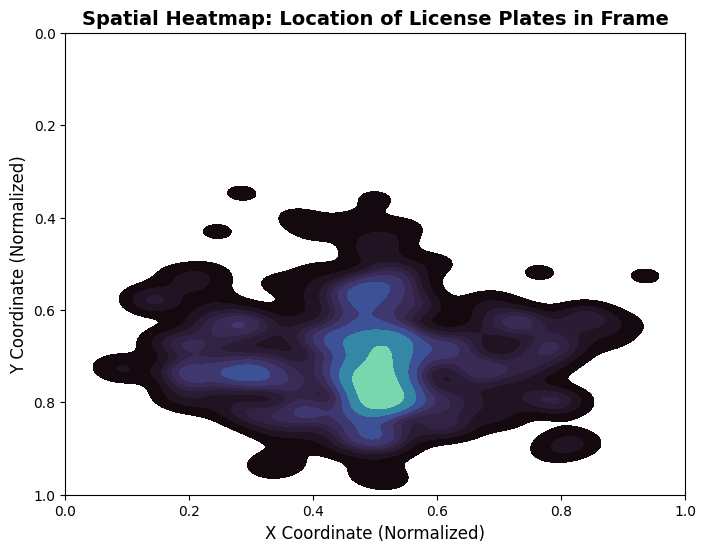

In [4]:
x_centers = []
y_centers = []

for file in label_files:
    with open(file, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) == 5:
                x_centers.append(float(parts[1]))
                y_centers.append(float(parts[2]))

plt.figure(figsize=(8, 6))
sns.kdeplot(x=x_centers, y=y_centers, cmap="mako", fill=True, bw_adjust=0.5)
plt.xlim(0, 1)
plt.ylim(1, 0) 
plt.title('Spatial Heatmap: Location of License Plates in Frame', fontsize=14, fontweight='bold')
plt.xlabel('X Coordinate (Normalized)', fontsize=12)
plt.ylabel('Y Coordinate (Normalized)', fontsize=12)
plt.show()